In [1]:
from rdkit import Chem

In [3]:
m = Chem.MolFromSmiles('Cc1ccccc1');



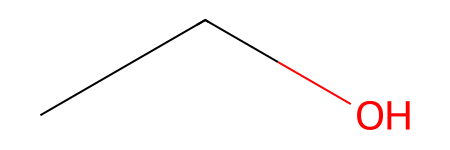

In [4]:
from rdkit import Chem

smiles = "CCO"
mol = Chem.MolFromSmiles(smiles)

mol

In [5]:
print("Number of atoms:", mol.GetNumAtoms())
print("Number of bonds:", mol.GetNumBonds())

Number of atoms: 3
Number of bonds: 2


In [6]:
mol_H = Chem.AddHs(mol)

print("Without explicit H:", mol.GetNumAtoms())
print("With explicit H:", mol_H.GetNumAtoms())

Without explicit H: 3
With explicit H: 9


In [7]:
mol_H = Chem.AddHs(mol)

print("Without explicit H:", mol.GetNumAtoms())
print("With explicit H:", mol_H.GetNumAtoms())

Without explicit H: 3
With explicit H: 9


In [8]:
for atom in mol.GetAtoms():
    print(
        atom.GetIdx(),
        atom.GetSymbol(),
        atom.GetAtomicNum()
    )

0 C 6
1 C 6
2 O 8


In [9]:
for atom in mol.GetAtoms():
    print(
        "Index:", atom.GetIdx(),
        "Element:", atom.GetSymbol(),
        "Atomic number:", atom.GetAtomicNum(),
        "Aromatic:", atom.GetIsAromatic()
    )

Index: 0 Element: C Atomic number: 6 Aromatic: False
Index: 1 Element: C Atomic number: 6 Aromatic: False
Index: 2 Element: O Atomic number: 8 Aromatic: False


In [16]:
molecules = {
    "ethanol": "CCO",
    "benzene": "c1ccccc1",
    "acetic_acid": "CC(=O)O",
    "caffeine": "Cn1c(=O)c2c(ncn2C)n(C)c1=O"
}

for name, smi in molecules.items():
    mol = Chem.MolFromSmiles(smi)
    mol
    print(name, mol.GetNumAtoms())

ethanol 3
benzene 6
acetic_acid 4
caffeine 14


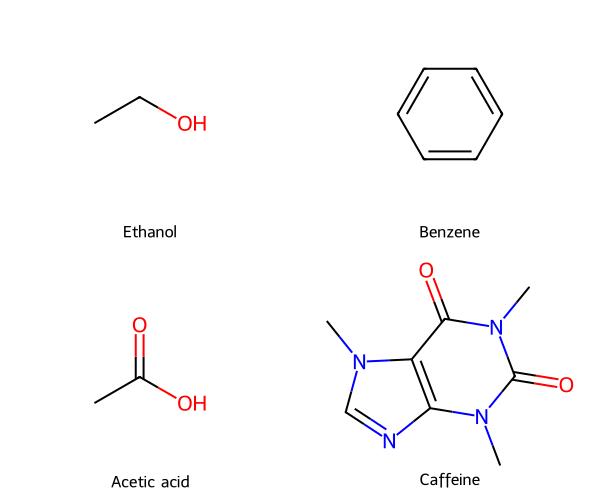

In [17]:
from rdkit import Chem
from rdkit.Chem import Draw

molecules = {
    "Ethanol": "CCO",
    "Benzene": "c1ccccc1",
    "Acetic acid": "CC(=O)O",
    "Caffeine": "Cn1c(=O)c2c(ncn2C)n(C)c1=O"
}

# Convert all SMILES into RDKit molecule objects
mols = []
names = []

for name, smi in molecules.items():
    mol = Chem.MolFromSmiles(smi)
    mols.append(mol)
    names.append(name)

# Display all molecules
Draw.MolsToGridImage(
    mols,
    legends=names,
    molsPerRow=2,
    subImgSize=(300, 250)
)

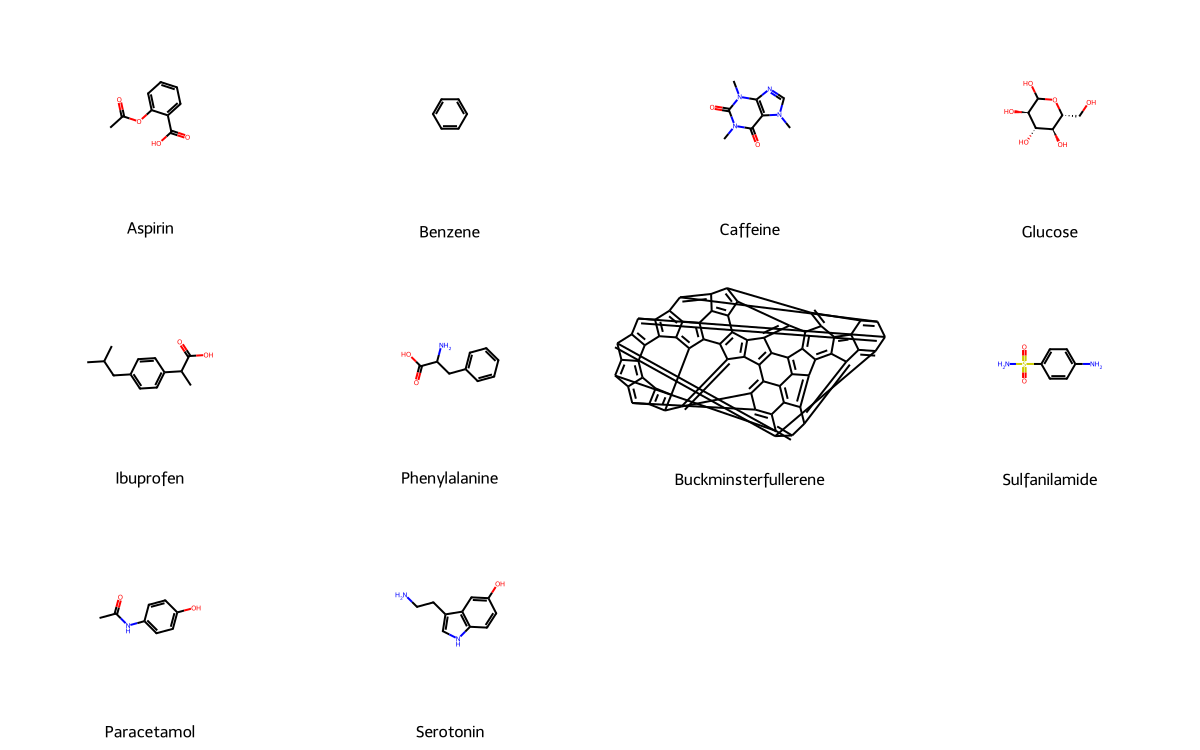

In [19]:
# Dictionary of 10 useful RDKit molecules with their SMILES
molecules = {
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Benzene": "c1ccccc1",
    "Caffeine": "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Glucose": "C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Phenylalanine": "NC(Cc1ccccc1)C(=O)O",
    "Buckminsterfullerene": "c12c3c4c5c6c1c7c8c2c9c1c3c3c2c4c4c5c5c6c6c7c7c8c8c9c9c1c1c3c3c2c2c4c4c5c5c6c6c7c7c8c8c9c1c1c3c3c2c2c4c4c5c5c6c6c7c7c8c8c1c3c2c4c5c6c78",
    "Sulfanilamide": "Nc1ccc(S(N)(=O)=O)cc1",
    "Paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "Serotonin": "NCCc1c[nH]c2ccc(O)cc12"
}

# Example: Convert SMILES to RDKit Mol objects
#mols = {name: Chem.MolFromSmiles(smiles) for name, smiles in molecules_smiles.items()}
# Convert all SMILES into RDKit molecule objects
mols = []
names = []

for name, smi in molecules.items():
    mol = Chem.MolFromSmiles(smi)
    mols.append(mol)
    names.append(name)

# Display all molecules
Draw.MolsToGridImage(
    mols,
    legends=names,
    molsPerRow=4,
    subImgSize=(300, 250)
)

In [20]:
from rdkit.Chem import Descriptors

In [21]:
mol = Chem.MolFromSmiles("CCO")

print("Molecular Weight:", Descriptors.MolWt(mol))
print("LogP:", Descriptors.MolLogP(mol))
print("TPSA:", Descriptors.TPSA(mol))
print("H-bond Donors:", Descriptors.NumHDonors(mol))
print("H-bond Acceptors:", Descriptors.NumHAcceptors(mol))
print("Rotatable Bonds:", Descriptors.NumRotatableBonds(mol))

Molecular Weight: 46.069
LogP: -0.0014000000000000123
TPSA: 20.23
H-bond Donors: 1
H-bond Acceptors: 1
Rotatable Bonds: 0


In [22]:
def calculate_descriptors(mol):
    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "Rotatable_Bonds": Descriptors.NumRotatableBonds(mol)
    }

In [23]:
calculate_descriptors(Chem.MolFromSmiles("CCO"))

{'MW': 46.069,
 'LogP': -0.0014000000000000123,
 'TPSA': 20.23,
 'HBD': 1,
 'HBA': 1,
 'Rotatable_Bonds': 0}

In [24]:
data = []

for name, smi in molecules.items():
    mol = Chem.MolFromSmiles(smi)

    desc = calculate_descriptors(mol)

    desc["Name"] = name
    desc["SMILES"] = smi

    data.append(desc)

In [25]:
data

[{'MW': 180.15899999999996,
  'LogP': 1.3101,
  'TPSA': 63.60000000000001,
  'HBD': 1,
  'HBA': 3,
  'Rotatable_Bonds': 2,
  'Name': 'Aspirin',
  'SMILES': 'CC(=O)Oc1ccccc1C(=O)O'},
 {'MW': 78.11399999999999,
  'LogP': 1.6866,
  'TPSA': 0.0,
  'HBD': 0,
  'HBA': 0,
  'Rotatable_Bonds': 0,
  'Name': 'Benzene',
  'SMILES': 'c1ccccc1'},
 {'MW': 194.194,
  'LogP': -1.0293,
  'TPSA': 61.82,
  'HBD': 0,
  'HBA': 3,
  'Rotatable_Bonds': 0,
  'Name': 'Caffeine',
  'SMILES': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'},
 {'MW': 180.156,
  'LogP': -3.2213999999999987,
  'TPSA': 110.38000000000001,
  'HBD': 5,
  'HBA': 6,
  'Rotatable_Bonds': 1,
  'Name': 'Glucose',
  'SMILES': 'C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O'},
 {'MW': 206.28499999999997,
  'LogP': 3.073200000000001,
  'TPSA': 37.3,
  'HBD': 1,
  'HBA': 1,
  'Rotatable_Bonds': 4,
  'Name': 'Ibuprofen',
  'SMILES': 'CC(C)Cc1ccc(cc1)C(C)C(=O)O'},
 {'MW': 165.19199999999995,
  'LogP': 0.641,
  'TPSA': 63.32000000000001,
  'HBD': 2,
  'HBA': 2,
  'Ro

In [26]:
import pandas as pd

df = pd.DataFrame(data)

df

,MW,LogP,TPSA,HBD,HBA,Rotatable_Bonds,Name,SMILES
0,180.159,1.3101,63.60,1,3,2,Aspirin,CC(=O)Oc1ccccc1C(=O)O
1,78.114,1.6866,0.00,0,0,0,Benzene,c1ccccc1
2,194.194,-1.0293,61.82,0,3,0,Caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C
3,180.156,-3.2214,110.38,5,6,1,Glucose,C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O
4,206.285,3.0732,37.30,1,1,4,Ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O
5,165.192,0.6410,63.32,2,2,3,Phenylalanine,NC(Cc1ccccc1)C(=O)O
6,792.726,19.5030,0.00,0,0,0,Buckminsterfullerene,c12c3c4c5c6c1c7c8c2c9c1c3c3c2c4c4c5c5c6c6c7c7c...
7,172.209,-0.0838,86.18,2,3,1,Sulfanilamide,Nc1ccc(S(N)(=O)=O)cc1
8,151.165,1.3506,49.33,2,2,1,Paracetamol,CC(=O)Nc1ccc(O)cc1
9,176.219,1.3747,62.04,3,2,2,Serotonin,NCCc1c[nH]c2ccc(O)cc12


In [27]:
df = df[
    ["Name", "SMILES", "MW", "LogP",
     "TPSA", "HBD", "HBA", "Rotatable_Bonds"]
]

df

,Name,SMILES,MW,LogP,TPSA,HBD,HBA,Rotatable_Bonds
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O,180.159,1.3101,63.60,1,3,2
1,Benzene,c1ccccc1,78.114,1.6866,0.00,0,0,0
2,Caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,194.194,-1.0293,61.82,0,3,0
3,Glucose,C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O,180.156,-3.2214,110.38,5,6,1
4,Ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,206.285,3.0732,37.30,1,1,4
5,Phenylalanine,NC(Cc1ccccc1)C(=O)O,165.192,0.6410,63.32,2,2,3
6,Buckminsterfullerene,c12c3c4c5c6c1c7c8c2c9c1c3c3c2c4c4c5c5c6c6c7c7c...,792.726,19.5030,0.00,0,0,0
7,Sulfanilamide,Nc1ccc(S(N)(=O)=O)cc1,172.209,-0.0838,86.18,2,3,1
8,Paracetamol,CC(=O)Nc1ccc(O)cc1,151.165,1.3506,49.33,2,2,1
9,Serotonin,NCCc1c[nH]c2ccc(O)cc12,176.219,1.3747,62.04,3,2,2


In [28]:
df.sort_values("Rotatable_Bonds", ascending=False)
#High LogP ->Favour non-polar environment relative to water-> high hydrophobicity (means lipophilic, or "fat-loving").
#High TPSA ->Highly Polar-> too many donors/acceptors -> has a hard time crossing cellular barriers by passive diffusion: Verbes rule
#HBA & HBD ->Drug-like molecule ideally should have HBA<5 and HBD<10: Lipsin
#Rotable_Bonds ->structural flexibility 

,Name,SMILES,MW,LogP,TPSA,HBD,HBA,Rotatable_Bonds
4,Ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,206.285,3.0732,37.30,1,1,4
5,Phenylalanine,NC(Cc1ccccc1)C(=O)O,165.192,0.6410,63.32,2,2,3
9,Serotonin,NCCc1c[nH]c2ccc(O)cc12,176.219,1.3747,62.04,3,2,2
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O,180.159,1.3101,63.60,1,3,2
8,Paracetamol,CC(=O)Nc1ccc(O)cc1,151.165,1.3506,49.33,2,2,1
3,Glucose,C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O,180.156,-3.2214,110.38,5,6,1
7,Sulfanilamide,Nc1ccc(S(N)(=O)=O)cc1,172.209,-0.0838,86.18,2,3,1
1,Benzene,c1ccccc1,78.114,1.6866,0.00,0,0,0
2,Caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,194.194,-1.0293,61.82,0,3,0
6,Buckminsterfullerene,c12c3c4c5c6c1c7c8c2c9c1c3c3c2c4c4c5c5c6c6c7c7c...,792.726,19.5030,0.00,0,0,0


In [29]:
df.to_csv("day01_molecular_descriptors.csv", index=False)

In [30]:
#Hydrophobilicity
#Wildman-Crippen LogP (Crippen's LogP):
from rdkit.Chem import Crippen

# Calculate LogP for Ibuprofen (Hydrophobic)
mol_ibu = Chem.MolFromSmiles("CC(C)Cc1ccc(cc1)C(C)C(=O)O")
logp_ibu = Crippen.MolLogP(mol_ibu)
print(f"Ibuprofen LogP: {logp_ibu:.2f}")  # Outputs approx 3.07

# Calculate LogP for Glucose (Hydrophilic)
mol_glu = Chem.MolFromSmiles("C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O")
logp_glu = Crippen.MolLogP(mol_glu)
print(f"Glucose LogP: {logp_glu:.2f}")   # Outputs approx -3.19


Ibuprofen LogP: 3.07
Glucose LogP: -3.22


In [31]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
###BBB- Blood Brain Barrier
# 10 molecules
molecules_smiles = {
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Benzene": "c1ccccc1",
    "Caffeine": "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Glucose": "C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Phenylalanine": "NC(Cc1ccccc1)C(=O)O",
    "Buckminsterfullerene": "c12c3c4c5c6c1c7c8c2c9c1c3c3c2c4c4c5c5c6c6c7c7c8c8c9c9c1c1c3c3c2c2c4c4c5c5c6c6c7c7c8c8c9c1c1c3c3c2c2c4c4c5c5c6c6c7c7c8c8c1c3c2c4c5c6c78",
    "Sulfanilamide": "Nc1ccc(S(N)(=O)=O)cc1",
    "Paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "Serotonin": "NCCc1c[nH]c2ccc(O)cc12"
}

tpsa_results = []
for name, smiles in molecules_smiles.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        tpsa = rdMolDescriptors.CalcTPSA(mol)
        tpsa_results.append((name, tpsa))

# Sort from highest TPSA to lowest TPSA
tpsa_results.sort(key=lambda x: x[1], reverse=True)

# Print results
print(f"{'Molecule':<22} | {'TPSA (Å²)':<10} | {'Permeability Context'}")
print("-" * 65)
for name, tpsa in tpsa_results:
    if tpsa > 140:
        context = "Very High (Poor Oral Absorption)"
    elif tpsa > 90:
        context = "High (Good Oral absorption, No Brain entry)"
    elif tpsa > 0:
        context = "Low/Moderate (Can cross BBB easily)"
    else:
        context = "Zero Polarity"
    print(f"{name:<22} | {tpsa:<10.2f} | {context}")


Molecule               | TPSA (Å²)  | Permeability Context
-----------------------------------------------------------------
Glucose                | 110.38     | High (Good Oral absorption, No Brain entry)
Sulfanilamide          | 86.18      | Low/Moderate (Can cross BBB easily)
Aspirin                | 63.60      | Low/Moderate (Can cross BBB easily)
Phenylalanine          | 63.32      | Low/Moderate (Can cross BBB easily)
Serotonin              | 62.04      | Low/Moderate (Can cross BBB easily)
Caffeine               | 61.82      | Low/Moderate (Can cross BBB easily)
Paracetamol            | 49.33      | Low/Moderate (Can cross BBB easily)
Ibuprofen              | 37.30      | Low/Moderate (Can cross BBB easily)
Benzene                | 0.00       | Zero Polarity
Buckminsterfullerene   | 0.00       | Zero Polarity


In [34]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Crippen, rdMolDescriptors

# 10 Benchmark molecules
molecules_smiles = {
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Benzene": "c1ccccc1",
    "Caffeine": "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Glucose": "C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Phenylalanine": "NC(Cc1ccccc1)C(=O)O",
    "Buckminsterfullerene": "c12c3c4c5c6c1c7c8c2c9c1c3c3c2c4c4c5c5c6c6c7c7c8c8c9c9c1c1c3c3c2c2c4c4c5c5c6c6c7c7c8c8c9c1c1c3c3c2c2c4c4c5c5c6c6c7c7c8c8c1c3c2c4c5c6c78",
    "Sulfanilamide": "Nc1ccc(S(N)(=O)=O)cc1",
    "Paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "Serotonin": "NCCc1c[nH]c2ccc(O)cc12"
}

# Collect properties
names, logps, tpsas, veber_pass = [], [], [], []

print(f"{'Molecule':<22} | {'LogP':<6} | {'TPSA':<6} | {'RotB':<4} | {'Veber Status'}")
print("-" * 60)

for name, smiles in molecules_smiles.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        logp = Crippen.MolLogP(mol)
        tpsa = rdMolDescriptors.CalcTPSA(mol)
        rot_bonds = rdMolDescriptors.CalcNumRotatableBonds(mol)
        
        # Veber's Filter: TPSA <= 140 AND Rotatable Bonds <= 10
        passes_veber = "PASSED" if (tpsa <= 140 and rot_bonds <= 10) else "FAILED"
        
        print(f"{name:<22} | {logp:<6.2f} | {tpsa:<6.2f} | {rot_bonds:<4} | {passes_veber}")
        
        names.append(name)
        logps.append(logp)
        tpsas.append(tpsa)
        veber_pass.append(passes_veber)




Molecule               | LogP   | TPSA   | RotB | Veber Status
------------------------------------------------------------
Aspirin                | 1.31   | 63.60  | 2    | PASSED
Benzene                | 1.69   | 0.00   | 0    | PASSED
Caffeine               | -1.03  | 61.82  | 0    | PASSED
Glucose                | -3.22  | 110.38 | 1    | PASSED
Ibuprofen              | 3.07   | 37.30  | 4    | PASSED
Phenylalanine          | 0.64   | 63.32  | 3    | PASSED
Buckminsterfullerene   | 19.50  | 0.00   | 0    | PASSED
Sulfanilamide          | -0.08  | 86.18  | 1    | PASSED
Paracetamol            | 1.35   | 49.33  | 1    | PASSED
Serotonin              | 1.37   | 62.04  | 2    | PASSED


In [37]:

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

# Your 10 molecules
molecules_smiles = {
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Benzene": "c1ccccc1",
    "Caffeine": "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Glucose": "C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Phenylalanine": "NC(Cc1ccccc1)C(=O)O",
    "Buckminsterfullerene": "c12c3c4c5c6c1c7c8c2c9c1c3c3c2c4c4c5c5c6c6c7c7c8c8c9c9c1c1c3c3c2c2c4c4c5c5c6c6c7c7c8c8c9c1c1c3c3c2c2c4c4c5c5c6c6c7c7c8c8c1c3c2c4c5c6c78",
    "Sulfanilamide": "Nc1ccc(S(N)(=O)=O)cc1",
    "Paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "Serotonin": "NCCc1c[nH]c2ccc(O)cc12"
}

print(f"{'Molecule':<22} | {'HBD (Donor)':<11} | {'HBA (Acceptor)':<14} | {'Lipinski Status'}")
print("-" * 65)

for name, smiles in molecules_smiles.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        hbd = rdMolDescriptors.CalcNumHBD(mol)
        hba = rdMolDescriptors.CalcNumHBA(mol)
        
        # Check rule of 5 conditions
        status = "PASSED" if (hbd <= 5 and hba <= 10) else "FAILED"
        print(f"{name:<22} | {hbd:<11} | {hba:<14} | {status}")

Molecule               | HBD (Donor) | HBA (Acceptor) | Lipinski Status
-----------------------------------------------------------------
Aspirin                | 1           | 3              | PASSED
Benzene                | 0           | 0              | PASSED
Caffeine               | 0           | 3              | PASSED
Glucose                | 5           | 6              | PASSED
Ibuprofen              | 1           | 1              | PASSED
Phenylalanine          | 2           | 2              | PASSED
Buckminsterfullerene   | 0           | 0              | PASSED
Sulfanilamide          | 2           | 3              | PASSED
Paracetamol            | 2           | 2              | PASSED
Serotonin              | 3           | 2              | PASSED


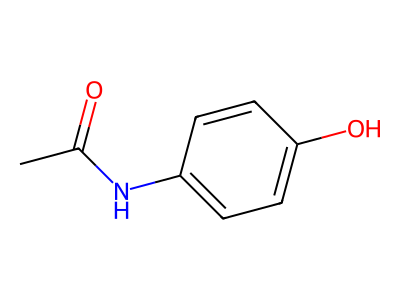

In [38]:
from rdkit import Chem
from rdkit.Chem import Draw

paracetamol = Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1")
Draw.MolToImage(paracetamol, size=(400, 300))

In [39]:
selected = {
    "Benzene": "c1ccccc1",
    "Glucose": "C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O",
    "Paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O"
}

In [40]:
from rdkit.Chem import Descriptors

for name, smi in selected.items():
    mol = Chem.MolFromSmiles(smi)

    print(
        name,
        "HBD =", Descriptors.NumHDonors(mol),
        "HBA =", Descriptors.NumHAcceptors(mol)
    )

Benzene HBD = 0 HBA = 0
Glucose HBD = 5 HBA = 6
Paracetamol HBD = 2 HBA = 2
Ibuprofen HBD = 1 HBA = 1


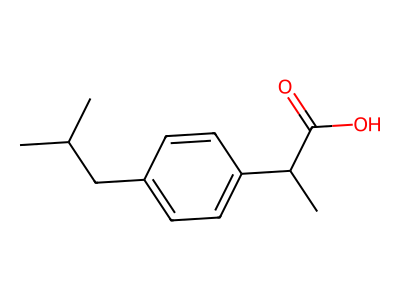

In [41]:
from rdkit import Chem
from rdkit.Chem import Draw

Ibuprofen = Chem.MolFromSmiles("CC(C)Cc1ccc(cc1)C(C)C(=O)O")
Draw.MolToImage(Ibuprofen, size=(400, 300))

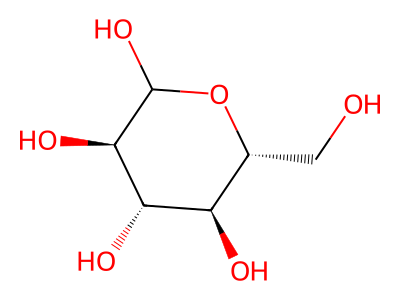

In [43]:
from rdkit import Chem
from rdkit.Chem import Draw

Glucose = Chem.MolFromSmiles("C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O")
Draw.MolToImage(Glucose, size=(400, 300))

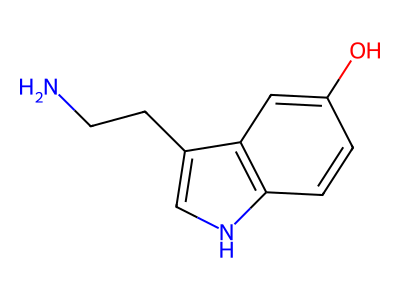

In [45]:
from rdkit import Chem
from rdkit.Chem import Draw

Serotonin = Chem.MolFromSmiles("NCCc1c[nH]c2ccc(O)cc12")
Draw.MolToImage(Serotonin, size=(400, 300))

In [46]:
benzene = Chem.MolFromSmiles("c1ccccc1")

for atom in benzene.GetAtoms():
    print(
        atom.GetIdx(),
        atom.GetSymbol(),
        atom.GetIsAromatic()
    )

0 C True
1 C True
2 C True
3 C True
4 C True
5 C True


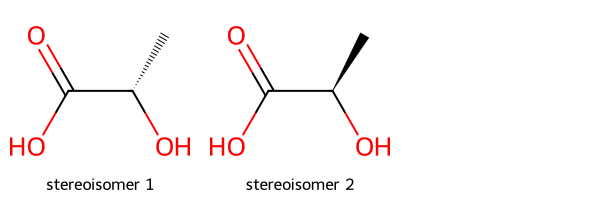

In [47]:
mol1 = Chem.MolFromSmiles("C[C@H](O)C(=O)O")
mol2 = Chem.MolFromSmiles("C[C@@H](O)C(=O)O")

Draw.MolsToGridImage(
    [mol1, mol2],
    legends=["stereoisomer 1", "stereoisomer 2"]
)

In [8]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

ibuprofen = Chem.MolFromSmiles(
    "CC(C)Cc1ccc(cc1)C(C)C(=O)O"
)

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

fp = morgan_gen.GetFingerprint(ibuprofen)
fp_list = list(fp)
#print(fp_list)

In [3]:
print("Fingerprint length:", fp.GetNumBits())

Fingerprint length: 2048


In [4]:
print("Number of ON bits:", fp.GetNumOnBits())

Number of ON bits: 25


In [6]:
on_bits = list(fp.GetOnBits())
print(on_bits)

[1, 79, 80, 283, 310, 389, 650, 807, 854, 857, 900, 921, 955, 1057, 1146, 1257, 1365, 1380, 1750, 1754, 1844, 1847, 1853, 1873, 1917]


In [9]:
print("Fingerprint size:", len(fp))
print("Number of ON bits:", fp.GetNumOnBits())
print("ON bits:", list(fp.GetOnBits()))

Fingerprint size: 2048
Number of ON bits: 25
ON bits: [1, 79, 80, 283, 310, 389, 650, 807, 854, 857, 900, 921, 955, 1057, 1146, 1257, 1365, 1380, 1750, 1754, 1844, 1847, 1853, 1873, 1917]


In [10]:
# 79 means fingerprint position 79 is ON, 
#Not that the molecule has “feature number 79” with an immediately obvious chemical interpretation

In [13]:
from rdkit import DataStructs
ibuprofen = Chem.MolFromSmiles(
    "CC(C)Cc1ccc(cc1)C(C)C(=O)O"
)
Paracetamol =  Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1"
               )
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)
fp_ibuprofen =  morgan_gen.GetFingerprint(ibuprofen)
fp_paracetamol =  morgan_gen.GetFingerprint(Paracetamol)

similarity = DataStructs.TanimotoSimilarity(
    fp_ibuprofen,
    fp_paracetamol
)

print("Tanimoto similarity:", similarity)

Tanimoto similarity: 0.18421052631578946


In [24]:

#Initialize the Morgan Fingerprint generator (Radius 2 is standard)
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2)

# 3. Generate fingerprints and store them in a dictionary
fingerprints = {}
for name, smiles in molecules_smiles.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:  # Ensure the molecule was parsed successfully
        fingerprints[name] = morgan_gen.GetFingerprint(mol)
        print("Number of ON bits:", name,"-", fingerprints[name].GetNumOnBits())
          
pairs = [
    ("Ibuprofen", "Paracetamol"),
    ("Ibuprofen", "Benzene"),
    ("Glucose", "Benzene"),
    ("Paracetamol", "Aspirin"),
    ("Serotonin", "Phenylalanine")
]

for a, b in pairs:
    # Safely get the fingerprints from the dictionary
    fp_a = fingerprints.get(a)
    fp_b = fingerprints.get(b)
    
    if fp_a and fp_b:
        sim = DataStructs.TanimotoSimilarity(fp_a, fp_b)
        print(f"{a} - {b} : {round(sim, 3)}")
    else:
        print(f"Error: Missing fingerprint for {a} or {b}")

Number of ON bits: Aspirin - 24
Number of ON bits: Benzene - 3
Number of ON bits: Caffeine - 25
Number of ON bits: Glucose - 17
Number of ON bits: Ibuprofen - 25
Number of ON bits: Phenylalanine - 22
Number of ON bits: Buckminsterfullerene - 3
Number of ON bits: Sulfanilamide - 17
Number of ON bits: Paracetamol - 20
Number of ON bits: Serotonin - 29
Ibuprofen - Paracetamol : 0.184
Ibuprofen - Benzene : 0.077
Glucose - Benzene : 0.0
Paracetamol - Aspirin : 0.222
Serotonin - Phenylalanine : 0.133


In [25]:
a = set(fingerprints["Ibuprofen"].GetOnBits())
b = set(fingerprints["Paracetamol"].GetOnBits())

shared = a.intersection(b)
union = a.union(b)

print("Ibuprofen bits:", len(a))
print("Paracetamol bits:", len(b))
print("Shared bits:", len(shared))
print("Union bits:", len(union))
print("Tanimoto:", len(shared) / len(union))

Ibuprofen bits: 25
Paracetamol bits: 20
Shared bits: 7
Union bits: 38
Tanimoto: 0.18421052631578946


In [26]:
sim = DataStructs.TanimotoSimilarity(
    fingerprints["Benzene"],
    fingerprints["Buckminsterfullerene"]
)

print(sim)

0.0


In [27]:
benzene_bits = set(fingerprints["Benzene"].GetOnBits())
fullerene_bits = set(fingerprints["Buckminsterfullerene"].GetOnBits())

print("Benzene:", benzene_bits)
print("Fullerene:", fullerene_bits)

shared = benzene_bits.intersection(fullerene_bits)

print("Shared:", shared)
print("Number shared:", len(shared))

sim = DataStructs.TanimotoSimilarity(
    fingerprints["Benzene"],
    fingerprints["Buckminsterfullerene"]
)

print("Tanimoto:", sim)

Benzene: {1088, 1873, 389}
Fullerene: {1984, 58, 1380}
Shared: set()
Number shared: 0
Tanimoto: 0.0


In [28]:
#Similarity Matrix
import pandas as pd
from rdkit import DataStructs

names = list(fingerprints.keys())

similarity_matrix = []

for name1 in names:
    row = []

    for name2 in names:
        sim = DataStructs.TanimotoSimilarity(
            fingerprints[name1],
            fingerprints[name2]
        )
        row.append(sim)

    similarity_matrix.append(row)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=names,
    columns=names
)

similarity_df.round(2)

,Aspirin,Benzene,Caffeine,Glucose,Ibuprofen,Phenylalanine,Buckminsterfullerene,Sulfanilamide,Paracetamol,Serotonin
Aspirin,1.00,0.12,0.09,0.02,0.20,0.28,0.04,0.11,0.22,0.08
Benzene,0.12,1.00,0.04,0.00,0.08,0.14,0.00,0.05,0.05,0.03
Caffeine,0.09,0.04,1.00,0.00,0.09,0.07,0.04,0.08,0.10,0.04
Glucose,0.02,0.00,0.00,1.00,0.11,0.08,0.00,0.00,0.03,0.05
Ibuprofen,0.20,0.08,0.09,0.11,1.00,0.38,0.04,0.11,0.18,0.10
Phenylalanine,0.28,0.14,0.07,0.08,0.38,1.00,0.04,0.15,0.20,0.13
Buckminsterfullerene,0.04,0.00,0.04,0.00,0.04,0.04,1.00,0.05,0.05,0.03
Sulfanilamide,0.11,0.05,0.08,0.00,0.11,0.15,0.05,1.00,0.12,0.12
Paracetamol,0.22,0.05,0.10,0.03,0.18,0.20,0.05,0.12,1.00,0.17
Serotonin,0.08,0.03,0.04,0.05,0.10,0.13,0.03,0.12,0.17,1.00


Total names to process: 10
Aspirin -> most similar to Phenylalanine (Tanimoto: 0.278)
Benzene -> most similar to Phenylalanine (Tanimoto: 0.136)
Caffeine -> most similar to Paracetamol (Tanimoto: 0.098)
Glucose -> most similar to Ibuprofen (Tanimoto: 0.105)
Ibuprofen -> most similar to Phenylalanine (Tanimoto: 0.382)
Phenylalanine -> most similar to Ibuprofen (Tanimoto: 0.382)
Buckminsterfullerene -> most similar to Sulfanilamide (Tanimoto: 0.053)
Sulfanilamide -> most similar to Phenylalanine (Tanimoto: 0.147)
Paracetamol -> most similar to Aspirin (Tanimoto: 0.222)
Serotonin -> most similar to Paracetamol (Tanimoto: 0.167)
(10, 2048)
[0 0 0 ... 0 0 0]
Unique values: [0 1]
Total active features: 24
Shape: (2048,)
Number of zero-variance bits: 1922
Number of varying bits: 126
Zero-variance bits: 1922
Varying bits: 126
Original shape: (10, 2048)
After removing zero-variance bits: (10, 126)
PCA shape: (10, 2)
Explained variance ratio: [0.18792171 0.183906  ]
Total explained variance: 0.3

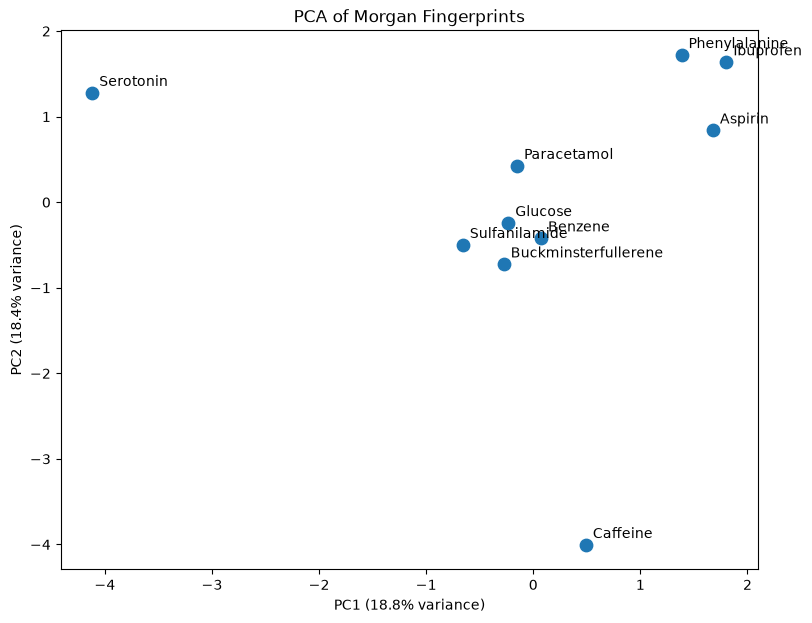

Ibuprofen - Phenylalanine | Tanimoto: 0.382 | PCA distance: 0.427
Glucose - Caffeine | Tanimoto: 0.0 | PCA distance: 3.832
Glucose - Buckminsterfullerene | Tanimoto: 0.0 | PCA distance: 0.485


In [62]:
import numpy as np
import pandas as pd
from rdkit import DataStructs

names = list(fingerprints.keys())
print(f"Total names to process: {len(names)}")
similarity_matrix = []
for name1 in names:
    row = []
    max_sim = -1.0
    best_match = None
    
    for name2 in names:
        sim = DataStructs.TanimotoSimilarity(
            fingerprints[name1],
            fingerprints[name2]
        )
        row.append(sim)
        
        # Track the maximum similarity and its corresponding name2 (excluding self)
        if name1 != name2 and sim > max_sim:
            max_sim = sim
            best_match = name2
            
    # Save the full row to our matrix
    similarity_matrix.append(row)
    
    # Print name1, the max similarity score, and the matching name2
    if best_match is not None:
        print(f"{name1} -> most similar to {best_match} (Tanimoto: {max_sim:.3f})")

# Optional: Convert your matrix into a pandas DataFrame
df_similarity = pd.DataFrame(similarity_matrix, index=names, columns=names)


X = []

for name in names:
    arr = np.zeros((2048,), dtype=int)

    DataStructs.ConvertToNumpyArray(
        fingerprints[name],
        arr
    )

    X.append(arr)

X = np.array(X)

print(X.shape)
print(X[0])
print("Unique values:", np.unique(X))
print("Total active features:", X[0].sum())
bit_variance = X.var(axis=0)
#-----------------------------------------------------------------|
print("Shape:", bit_variance.shape)
print("Number of zero-variance bits:", np.sum(bit_variance == 0))
print("Number of varying bits:", np.sum(bit_variance > 0))

bit_variance = X.var(axis=0)

print("Zero-variance bits:", np.sum(bit_variance == 0))
print("Varying bits:", np.sum(bit_variance > 0))
#------------------------------------------------------------------|
X_var = X[:, bit_variance > 0]

print("Original shape:", X.shape)
print("After removing zero-variance bits:", X_var.shape)
#_______________________________________________
!pip install scikit-learn
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_var)

print("PCA shape:", X_pca.shape)
print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)
#___________________________________________________
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=80
)

for i, name in enumerate(names):
    plt.annotate(
        name,
        (X_pca[i, 0], X_pca[i, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title("PCA of Morgan Fingerprints")
plt.show()

#-----------------------------------------------------------|
from scipy.spatial.distance import pdist, squareform

pca_distances = squareform(
    pdist(X_pca, metric="euclidean")
)

pca_distance_df = pd.DataFrame(
    pca_distances,
    index=names,
    columns=names
)

pca_distance_df.round(2)

#------------------------------------------------------|
from scipy.spatial.distance import pdist, squareform

pca_distances = squareform(
    pdist(X_pca, metric="euclidean")
)

pca_distance_df = pd.DataFrame(
    pca_distances,
    index=names,
    columns=names
)

pca_distance_df.round(2)


#-----------------------------------------------------|
pairs = [
    ("Ibuprofen", "Phenylalanine"),
    ("Glucose", "Caffeine"),
    ("Glucose", "Buckminsterfullerene")
]

for a, b in pairs:
    i = names.index(a)
    j = names.index(b)

    print(
        a, "-", b,
        "| Tanimoto:",
        round(DataStructs.TanimotoSimilarity(
            fingerprints[a],
            fingerprints[b]
        ), 3),
        "| PCA distance:",
        round(pca_distances[i, j], 3)
    )